In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
train_data = pd.read_csv('./dataset/fashion-mnist_train.csv')
test_data = pd.read_csv('./dataset/fashion-mnist_test.csv')

In [3]:
train_data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
test_data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
print(train_data.shape)
print(test_data.shape)

(60000, 785)
(10000, 785)


In [6]:
LABEL_NAMES = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot",
}

def display_image(df, index):
    image_data = df.iloc[index, 1:].values.reshape(28, 28)
    plt.figure(figsize=(3, 3))
    plt.imshow(image_data, cmap='gray')
    plt.title(LABEL_NAMES[df.iloc[index, 0]])
    plt.show()





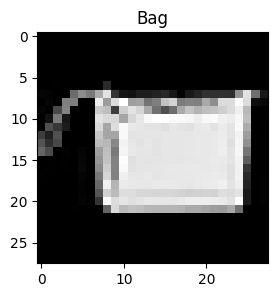

In [7]:
display_image(train_data, 68)

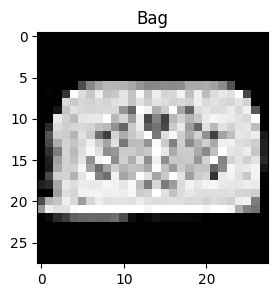

In [8]:
display_image(test_data, 6)

In [9]:
X_train = train_data.iloc[:, 1:].values
y_train = train_data.iloc[:, 0].values

X_test = test_data.iloc[:, 1:].values
y_test = test_data.iloc[:, 0].values

print(f"X_train shape: {X_train.shape} - y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape} - y_test shape: {y_test.shape}")


X_train shape: (60000, 784) - y_train shape: (60000,)
X_test shape: (10000, 784) - y_test shape: (10000,)


## Histogram

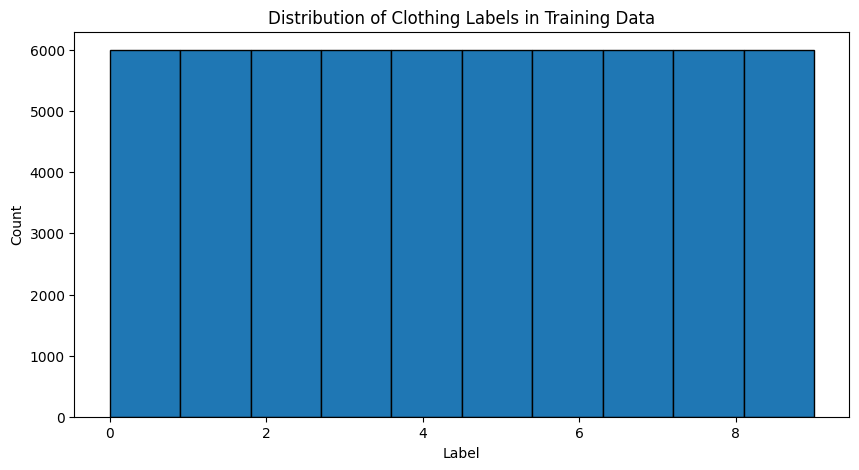

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(y_train, bins=10, edgecolor='black')
plt.title('Distribution of Clothing Labels in Training Data')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


100 => 80 train => 20 test

RED or BLUE

correct => 5, wrong => -5


1 => RED
2 => RED
3 => RED
4 => RED
...
80 => RED

60 RED , 20 BLUE

60/80 => 



TEST:
81 => RED

## pre-processing (0-1)

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
# print(f"Sample train data before scaling: {X_train[0]}")
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# print(f"Sample train data after scaling: {X_train[0]}")


## Model training

### KNN

In [12]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",50
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [13]:
# check the performance
y_pred = knn.predict(X_test)

In [15]:
def calculate_accuracy(y_pred, y_org):
    n_correct = 0
    for idx in range(len(y_pred)):
        if y_pred[idx] == y_org[idx]:
            n_correct += 1

    return n_correct/len(y_org)

In [16]:
print(f"Accuracy => {calculate_accuracy(y_pred, y_test)}")

Accuracy => 0.8308


In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



[[862   0  24  25   3   0  73   2  11   0]
 [  8 948  12  22   2   0   8   0   0   0]
 [ 14   0 754   7 112   0 108   0   5   0]
 [ 44  10  14 868  38   0  26   0   0   0]
 [  2   2  81  20 776   0 116   0   3   0]
 [  1   0   0   1   0 746  12 146   5  89]
 [229   1 115  18  76   0 549   0  12   0]
 [  0   0   0   0   0   6   0 918   0  76]
 [  3   1  17   3   7   0  20  17 930   2]
 [  0   0   0   0   0   2   1  40   0 957]]
0.8308
              precision    recall  f1-score   support

           0       0.74      0.86      0.80      1000
           1       0.99      0.95      0.97      1000
           2       0.74      0.75      0.75      1000
           3       0.90      0.87      0.88      1000
           4       0.77      0.78      0.77      1000
           5       0.99      0.75      0.85      1000
           6       0.60      0.55      0.57      1000
           7       0.82      0.92      0.86      1000
           8       0.96      0.93      0.95      1000
           9       0.

In [ ]:
# F1 score = 2 * (precision * recall) / (precision + recall)

# Example:
# precision = 0.5
# recall = 0.5
# F1 score = 2 * (0.5 * 0.5) / (0.5 + 0.5) = 0.5


# precision = 0
# recall = 100
# F1 score = 0

# precision = 0.6
# recall = 0.4
# F1 score = 2 * (0.6 * 0.4) / (0.6 + 0.4) = 0.48

# precision = 0.51
# recall = 0.49
# F1 score = 2 * (0.51 * 0.49) / (0.51 + 0.49) = 0.5

# precision = 0.49
# recall = 0.51
# F1 score = 2 * (0.49 * 0.51) / (0.49 + 0.51) = 0.5

# precision = 0.8
# recall = 0.4
# F1 score = 2 * (0.8 * 0.4) / (0.8 + 0.4) = 0.53



## Decision Tree

In [17]:
from sklearn.tree import DecisionTreeClassifier

# dt = DecisionTreeClassifier(max_depth=5, min_samples_split=4, min_samples_leaf=2)
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
print(f"Accuracy => {calculate_accuracy(y_pred, y_test)}")


Accuracy => 0.7999


## Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

# rf = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_split=4, min_samples_leaf=2)
rf = RandomForestClassifier(n_estimators=10)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(f"Accuracy => {calculate_accuracy(y_pred, y_test)}")


Accuracy => 0.8646


## SVM

In [22]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)
print(f"Accuracy => {calculate_accuracy(y_pred, y_test)}")

Accuracy => 0.8572


# logistic regression

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(f"Accuracy => {calculate_accuracy(y_pred, y_test)}")

Accuracy => 0.8565


/Users/hasan.abbasi/Documents/hsn/students/nilu/ML/venv/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## ANN

In [24]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(16, 8, 8), max_iter=1000)
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)
print(f"Accuracy => {calculate_accuracy(y_pred, y_test)}")

Accuracy => 0.8616
